In [1]:
print("Hello World")

Hello World


In [ ]:
TOGETHER_BASE_URL="https://api.together.ai/v1"
OPENAI_OSS_MODEL="OpenAI/gpt-oss-20B"
LIQUID_AI="LiquidAI/LFM2-24B-A2B"
QWEN="Qwen/Qwen3.5-9B"


In [3]:
import requests
import os
from langchain.tools import tool
from langchain_tavily import TavilySearch
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from langgraph.graph import StateGraph, END, START

from dotenv import load_dotenv
load_dotenv()

/home/yash/Desktop/Code/3. LangGraph and Ollama/langgraph_venv/lib/python3.13/site-packages/langgraph/checkpoint/serde/encrypted.py:5: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


True

In [4]:
llm = ChatOpenAI(
  model=QWEN,
  api_key=os.getenv("TOGETHER_API_KEY"),
  base_url=TOGETHER_BASE_URL
)

In [8]:
@tool(
    "calculator",
    description=(
        "Performs arithmetic and mathematical calculations. "
        "Use this tool for evaluating math expressions, basic arithmetic, "
        "scientific calculations, or solving numeric problems. "
        "Input should be a valid mathematical expression as a string "
        "(e.g., '25 * 4 + 10', 'sqrt(16)', '100 / 5'). "
        "Do NOT use for general reasoning, factual queries, or web lookups."
    )
)
def calc(expression: str) -> str:
    """Evaluate mathematical expressions."""
    return str(eval(expression))


@tool(
    "web_search",
    description=(
        "Searches the web for up-to-date or factual information. "
        "Use this tool when the question requires recent data, external knowledge, "
        "current events, factual lookups, company/product information, "
        "documentation, or anything not guaranteed to be in memory. "
        "Input should be a concise search query "
        "(e.g., 'latest LangChain version', 'weather in Hyderabad'). "
        "Do NOT use for math calculations or simple reasoning."
    )
)
def web_search(query: str):
    response = TavilySearch(
        max_results=3,
        topic="general",
        tavily_api_key=os.getenv("TAVILY_API_KEY")
        
    )
    return response.invoke(query)


@tool(
    "weather",
    description=(
        "Fetches real-time weather information for a specific location. "
        "Use this tool when the user asks about current weather conditions, "
        "temperature, humidity, rain, wind, or weather forecasts for a city or place. "
        "Input should be a location name as a string "
        "(e.g., 'Hyderabad', 'New York', 'London'). "
        "Use for weather-related questions like "
        "'What's the weather in Mumbai?' or "
        "'Is it raining in Bangalore?'. "
        "Do NOT use for general knowledge, math, or non-weather queries."
    )
)
def get_weather(location: str) -> str:
    url = f"https://wttr.in/{location}?format=j1"
    response = requests.get(url, timeout=10)

    response.raise_for_status()
    data = response.json()

    return data

# calc.invoke("2+2")
# web_search.invoke("HDFC")
# get_weather.invoke("Hyderabad")
all_tools = [calc, web_search, get_weather]

## Agent Node

In [9]:
import operator
from typing import Annotated, TypedDict


class AgentState(TypedDict):
  messages: Annotated[list, operator.add]

def agent_node(state:AgentState):
  messages = state['messages']
  llm_with_tools = llm.bind_tools(all_tools)
  response = llm_with_tools.invoke(messages)

  if hasattr(response, "tool_calls") and response.tool_calls:
    for tc in response.tool_calls:
      print(f"[AGENT] called Tool {tc.get("name", '?')} with args {tc.get('args', '?')}")
  else:
    print("[AGENT] Final Response....")

  return {
    "messages": [response]
  }

def should_continue(state:AgentState):
  last_message = state['messages'][-1]
  if hasattr(last_message, "tool_calls") and last_message.tool_calls:
    return "tools"
  return END

In [10]:
def create_agent():
  builder = StateGraph(AgentState)
  builder.add_node("agent", agent_node)
  builder.add_node("tools", ToolNode(all_tools))

  builder.add_edge(START, "agent")
  builder.add_conditional_edges("agent", should_continue, ['tools', END])
  builder.add_edge("tools", "agent")
  graph = builder.compile()
  return graph

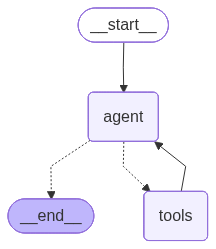

In [8]:
create_agent()

In [21]:
query_1="Hi"
query_2="WHat is the Weather of Hyderabad?"
query_4 = "What is the weather in Mumbai? and What is 4*56 and 3-90 and What is the Latest News on HDFC Math?"
query_5 = "What is the weather in Mumbai as per my Travel History Document"

In [19]:
from langchain_core.messages import HumanMessage


# resp = create_agent().invoke({'messages': [HumanMessage(query_5)]})

In [31]:

for message in resp['messages']:
  message.pretty_print() 

================================ Human Message =================================

What is the weather in Mumbai as per my Travel History Document
================================== Ai Message ==================================
Tool Calls:
  weather (call_ddbfeba58ece4a0e9f3b920d)
 Call ID: call_ddbfeba58ece4a0e9f3b920d
  Args:
    location: Mumbai
================================= Tool Message =================================
Name: weather

{"current_condition": [{"FeelsLikeC": "43", "FeelsLikeF": "110", "cloudcover": "50", "humidity": "63", "observation_time": "08:46 AM", "precipInches": "0.0", "precipMM": "0.0", "pressure": "1006", "pressureInches": "30", "temp_C": "34", "temp_F": "94", "uvIndex": "9", "visibility": "4", "visibilityMiles": "2", "weatherCode": "143", "weatherDesc": [{"value": "Haze"}], "weatherIconUrl": [{"value": "https://cdn.worldweatheronline.com/images/wsymbols01_png_64/wsymbol_0006_mist.png"}], "winddir16Point": "WSW", "winddirDegree": "256", "windspeedKmph": "2

## Persistance

In [14]:
from langgraph.checkpoint.memory import InMemorySaver
checkpointer = InMemorySaver()

def create_agent():
  builder = StateGraph(AgentState)
  builder.add_node("agent", agent_node)
  builder.add_node("tools", ToolNode(all_tools))

  builder.add_edge(START, "agent")
  builder.add_conditional_edges("agent", should_continue, ['tools', END])
  builder.add_edge("tools", "agent")
  
  graph = builder.compile(checkpointer=checkpointer)
  return graph


In [17]:
config = {"configurable": {"thread_id": "thread-1"}}
agent = create_agent()


In [26]:
result = agent.invoke({'messages': [HumanMessage(query_4)]}, config=config)

[AGENT] called Tool weather with args {'location': 'Mumbai'}
[AGENT] called Tool calculator with args {'expression': '4 * 56'}
[AGENT] called Tool calculator with args {'expression': '3 - 90'}
[AGENT] called Tool web_search with args {'query': 'HDFC bank latest news 2025'}
[AGENT] Final Response....


In [32]:
for message in result['messages']:
  message.pretty_print()

================================ Human Message =================================

Hi
================================== Ai Message ==================================

Hi there! 👋 How's it going? Is there anything I can help you with today?
================================ Human Message =================================

What is the weather in Mumbai as per my Travel History Document
================================== Ai Message ==================================

I don't have access to your personal documents, including any travel history records. However, I can help you check the **current weather in Mumbai** using real-time data! 🌤️ Would you like me to fetch the latest weather conditions there?
================================ Human Message =================================

What is the weather in Mumbai? and What is 4*56 and 3-90 and What is the Latest News on HDFC Math?
================================== Ai Message ==================================
Tool Calls:
  weather (call_0de

#### Stream Agent Output

In [34]:
def chat(query, thread_id):

    config = {"configurable": {"thread_id": thread_id}}

    for chunk in agent.stream({'messages': [query]}, config=config):

        if 'agent' in chunk:
            chunk = chunk.get('agent')
        else:
            chunk = chunk.get('tools')

        if hasattr(chunk, 'tool_calls') and chunk.tool_calls:
            for tc in chunk.tool_calls:
                print(f"[AGENT] called Tool {tc.get('name', '?')} with args {tc.get('args', '?')}")
        else:
            print(f"[AGENT/ToolMessage] Responding.\n{chunk['messages'][0].content}")

        # print(chunk)      

In [35]:
chat("Can you summarize what all questions i asked so far?", "thread-1")


[AGENT] Final Response....
[AGENT/ToolMessage] Responding.
Here's a summary of all the questions you've asked so far:

| # | Question | Category |
|---|----------|----------|
| 1 | "What is the weather in Mumbai as per my Travel History Document" | Weather (Personal Document) |
| 2 | "What is the weather in Mumbai?" | Weather (Real-time) |
| 3 | "What is 4*56 and 3-90" | Mathematics |
| 4 | "What is the Latest News on HDFC Math?" | News (Assumed to be HDFC Bank) |

### 📋 **Summary:**
You mainly asked about:
1. **Weather in Mumbai** (at first, referenced a personal document, then real-time current weather)
2. **Basic Math Calculations** (4 × 56 and 3 − 90)
3. **Latest News on HDFC** (bank-related news, despite the "Math" typo)

Is there anything else you'd like to know or discuss? 🌟


In [36]:
chat(query="Hello, I am Yash Kharche", thread_id="yash")

[AGENT] Final Response....
[AGENT/ToolMessage] Responding.
Hello Yash! Nice to meet you. How can I assist you today? Feel free to ask me any questions or let me know if you need help with anything specific.


In [37]:
chat(query="What is my Name?", thread_id="yash")

[AGENT] Final Response....
[AGENT/ToolMessage] Responding.
Your name is Yash Kharche, based on your introduction in this conversation. How can I help you?


## V1

In [9]:
from langchain.agents import create_agent


In [15]:
tools = all_tools
SYSTEM_PROMPT="""You are a helpful, precise assistant with access to three specialized tools:

1. **calculator** — Use for ALL arithmetic, math expressions, or numeric computations.
   - Trigger: percentages, unit conversions, formulas, any expression like '25 * 4', 'sqrt(16)', etc.
   - Do NOT use for general questions that mention numbers but don't require computation.

2. **web_search** — Use for current events, factual lookups, documentation, or any knowledge
   beyond your training data or that may have changed recently.
   - Trigger: "latest", "current", "who is", "what is X", product/company info, news, etc.
   - Keep queries short and specific (3–6 words) for best results.

3. **weather** — Use ONLY for real-time weather conditions, temperature, rain, or forecasts.
   - Trigger: "weather in X", "is it raining in Y", "temperature in Z".
   - Input must be a city/place name only.

## Tool Selection Rules
- Use the most specific tool available. Prefer `calculator` over `web_search` for math.
- Prefer `weather` over `web_search` for weather queries — it returns real-time structured data.
- If a query genuinely requires no tool (e.g., a simple factual definition you know with confidence),
  answer directly without invoking any tool.
- Never hallucinate tool outputs. If a tool returns no useful result, say so honestly.

## Response Style
- Be concise. Lead with the answer, add supporting detail after.
- When using a tool result, cite what the tool returned rather than restating it verbosely.
- If the user's intent is ambiguous, make a reasonable assumption, state it briefly, then answer.
"""

In [17]:
agent = create_agent(
  llm,
  tools,
  system_prompt=SYSTEM_PROMPT
)

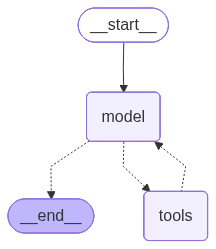

In [18]:
agent

In [47]:
query_1="Hi"
query_2="WHat is the Weather of Hyderabad?"
query_4 = "What is the weather in Mumbai? and What is 4*56 and 3-90 and What is the Latest News on HDFC Math?"
query_5 = "As per my Travel History Document What is the weather in Mumbai"

In [48]:
from langchain_core.messages import HumanMessage

inputs = {'messages': [HumanMessage(content=query_5)]}

In [49]:
for step in agent.stream(
    input=inputs,
    stream_mode="updates",
):
    for node_name, node_data in step.items():

        print(f"\nNODE: {node_name}")
        print("-" * 50)

        messages = node_data.get("messages", [])

        for msg in messages:
            msg_type = type(msg).__name__

            print(f"\n[{msg_type}]")

            if hasattr(msg, "tool_calls") and msg.tool_calls:
                for tool_call in msg.tool_calls:
                    print(f"Tool: {tool_call['name']}")
                    print(f"Args: {tool_call['args']}")

            if hasattr(msg, "content"):
                print("Content:")
                print(msg.content)


NODE: model
--------------------------------------------------

[AIMessage]
Tool: weather
Args: {'location': 'Mumbai'}
Content:


NODE: tools
--------------------------------------------------

[ToolMessage]
Content:
{"current_condition": [{"FeelsLikeC": "45", "FeelsLikeF": "112", "cloudcover": "50", "humidity": "60", "observation_time": "07:26 AM", "precipInches": "0.0", "precipMM": "0.0", "pressure": "1007", "pressureInches": "30", "temp_C": "34", "temp_F": "93", "uvIndex": "11", "visibility": "4", "visibilityMiles": "2", "weatherCode": "143", "weatherDesc": [{"value": "Haze"}], "weatherIconUrl": [{"value": "https://cdn.worldweatheronline.com/images/wsymbols01_png_64/wsymbol_0006_mist.png"}], "winddir16Point": "WSW", "winddirDegree": "250", "windspeedKmph": "21", "windspeedMiles": "13"}], "nearest_area": [{"areaName": [{"value": "Ballard Estate"}], "country": [{"value": "India"}], "latitude": "18.933", "longitude": "72.833", "population": "0", "region": [{"value": "Maharashtra"}], "